# BraTS 2020 — 2.5D U-Net++ (Nested Dense Skip Connections)

**모델**: U-Net++ with Deep Supervision
**입력**: `(B, 20, H, W)` — adjacent 5 slice × 4 modality
**출력**: `(B, 3, H, W)` — WT/TC/ET (중앙 slice 기준)

---

## 설계 플랜 (검색 + 논문 + 도메인 지식 기반)

### U-Net vs U-Net++ 차이
```
U-Net  skip: encoder_i → decoder_i (동일 해상도만 연결)
U-Net++ skip: X^{i,j} = Dense( X^{i,0}, ..., X^{i,j-1}, up(X^{i+1,j-1}) )
  → 중간 노드들이 dense하게 연결 → semantic gap 감소
  → 다중 스케일 특징 동시 활용 → 작은 ET 검출 향상
```

### 2.5D adjacent 5 slices 이유
```
[z-2, z-1, z, z+1, z+2] 5장 × 4 modality = 20채널 입력
→ 중앙 slice를 예측할 때 앞뒤 맥락 활용
→ 3D 전체보다 메모리 훨씬 적게 사용
→ LSTM보다 단순하지만 충분한 맥락 제공
```

### 위험요소 및 대응
| 위험 | 대응 |
|------|------|
| 과적합 (U-Net++가 더 많은 파라미터) | Dropout(0.3) + 강력한 증강 + PATIENCE=12 |
| Deep supervision 초기 불안정 | DS weight=0.3 (메인 0.7로 제한) |
| 경계 slice (앞뒤 없음) | reflect padding (zero보다 artifact 적음) |
| ET 희귀 클래스 | Tversky Loss (FN 가중치 β=0.7) |
| MPS backward 버그 | GroupNorm 전체 사용 |
| CosineAnnealing 진동 | WarmRestarts (T_0=10) 사용 |

In [37]:
import subprocess, sys
for pkg in ['nibabel', 'scikit-learn', 'monai']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('패키지 설치 완료')

You should consider upgrading via the '/Users/baiohelseu/Desktop/brats_work/venv/bin/python -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/baiohelseu/Desktop/brats_work/venv/bin/python -m pip install --upgrade pip' command.


패키지 설치 완료


You should consider upgrading via the '/Users/baiohelseu/Desktop/brats_work/venv/bin/python -m pip install --upgrade pip' command.


## 1. 임포트 및 Device

In [38]:
import random, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import nibabel as nib
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Device: mps (Metal GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('Device: cuda')
else:
    DEVICE = torch.device('cpu')
    print('Device: cpu')
print(f'PyTorch: {torch.__version__}')

Device: mps (Metal GPU)
PyTorch: 2.8.0


## 2. 경로 및 하이퍼파라미터

In [39]:
candidates = [
    Path.home() / 'Desktop' / 'brats_work' / 'brats20-dataset-training-validation',
    Path.home() / 'Downloads' / 'brats20-dataset-training-validation',
    Path.cwd() / 'brats20-dataset-training-validation',
]
DATA_ROOT = next((p for p in candidates if p.exists()), None)
if DATA_ROOT is None:
    DATA_ROOT = Path('/Users/hong-igdaebaiohelseu/Desktop/brats_work/brats20-dataset-training-validation')

TRAIN_DATA_DIR = DATA_ROOT / 'BraTS2020_TrainingData' / 'MICCAI_BraTS2020_TrainingData'
print(f'데이터: {TRAIN_DATA_DIR}')
print(f'존재: {TRAIN_DATA_DIR.exists()}')

WORK_DIR      = Path.home() / 'brats_work'
PROCESSED_DIR = WORK_DIR / 'processed_unetpp'
CKPT_DIR      = WORK_DIR / 'checkpoints_unetpp'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

N_ADJ       = 2
N_SLICES    = 2*N_ADJ + 1    # 5
IMG_SIZE    = 192
N_MODALITY  = 4
IN_CHANNELS = N_SLICES * N_MODALITY   # 20
N_CLASSES   = 3
BRAIN_THR   = 500
BASE        = 32
DS_WEIGHT   = 0.3
DROPOUT_P   = 0.3
BATCH_SIZE  = 8
LR          = 3e-4
WEIGHT_DECAY = 1e-5
N_EPOCHS    = 50
PATIENCE    = 12

print(f'입력 채널: {IN_CHANNELS} ({N_SLICES} slices x {N_MODALITY} modalities)')
print(f'배치: {BATCH_SIZE}, DS 가중치: {DS_WEIGHT}')

데이터: /Users/baiohelseu/Desktop/brats_work/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
존재: True
입력 채널: 20 (5 slices x 4 modalities)
배치: 8, DS 가중치: 0.3


## 3. 환자 목록 및 Split

In [40]:
def verify_patient(patient_dir):
    pid = patient_dir.name
    return all((patient_dir / f'{pid}_{m}.nii').exists()
               for m in ['flair', 't1', 't1ce', 't2', 'seg'])

all_patients   = sorted([d for d in TRAIN_DATA_DIR.iterdir() if d.is_dir()])
valid_patients = [p for p in all_patients if verify_patient(p)]
print(f'전체: {len(all_patients)}, 유효: {len(valid_patients)}')

patient_names = [p.name for p in valid_patients]
train_names, temp     = train_test_split(patient_names, test_size=0.3,   random_state=SEED)
val_names, test_names = train_test_split(temp,          test_size=0.667, random_state=SEED)
print(f'Train: {len(train_names)}, Val: {len(val_names)}, Test: {len(test_names)}')

split_df = pd.DataFrame({
    'patient': patient_names,
    'split': ['train' if n in train_names else ('val' if n in val_names else 'test')
              for n in patient_names]
})
split_df.to_csv(PROCESSED_DIR / 'patient_split.csv', index=False)
print('split 저장 완료')

전체: 369, 유효: 368
Train: 257, Val: 36, Test: 75
split 저장 완료


## 4. 전처리 함수

### 핵심 설계: Reflect Padding
```
경계 slice (z=0,1)에는 앞쪽 slice가 없음
Zero padding: 모델에게 잘못된 배경 신호 전달
Reflect padding: 거울 반사로 자연스럽게 패딩

예) D=155, N_ADJ=2:
  원본 인덱스: [0,1,2,...,154]
  패딩 후:    [2,1, 0,1,2,...,154, 153,152]
  z=0의 입력: [2,1,0,1,2]  (거울 반사)
  z=1의 입력: [1,0,1,2,3]
```

In [41]:
MODALITIES = ['flair', 't1ce', 't1', 't2']

def load_volume(patient_dir):
    pid  = patient_dir.name
    imgs = [nib.load(patient_dir / f'{pid}_{m}.nii').get_fdata(dtype=np.float32)
            for m in MODALITIES]
    image = np.stack(imgs, axis=-1)
    mask  = nib.load(patient_dir / f'{pid}_seg.nii').get_fdata(dtype=np.float32)
    return image, mask


def zscore_normalize(image):
    out = np.zeros_like(image)
    for c in range(image.shape[-1]):
        vol = image[..., c]
        bm  = vol > 0
        if bm.sum() == 0: continue
        out[..., c]  = (vol - vol[bm].mean()) / (vol[bm].std() + 1e-8)
        out[..., c] *= bm
    return out


def get_brain_bbox(image, margin=5):
    brain      = image.sum(axis=-1) > 0
    rows       = np.any(brain, axis=(1, 2))
    cols       = np.any(brain, axis=(0, 2))
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    H, W = image.shape[:2]
    return (max(0,rmin-margin), min(H-1,rmax+margin),
            max(0,cmin-margin), min(W-1,cmax+margin))


def crop_and_resize(image, mask, bbox, size=192):
    r0,r1,c0,c1 = bbox
    ic = image[r0:r1+1, c0:c1+1, :, :]
    mc = mask [r0:r1+1, c0:c1+1, :]
    h, w = ic.shape[:2]
    ir = np.zeros((size, size, ic.shape[2], N_MODALITY), dtype=np.float32)
    for c in range(N_MODALITY):
        ir[..., c] = zoom(ic[..., c], (size/h, size/w, 1), order=1)
    mr = zoom(mc, (size/h, size/w, 1), order=0)
    return ir, mr


def mask_to_regions(mask_2d):
    wt = (mask_2d > 0).astype(np.float32)
    tc = ((mask_2d == 1) | (mask_2d == 4)).astype(np.float32)
    et = (mask_2d == 4).astype(np.float32)
    return np.stack([wt, tc, et], axis=-1)


def reflect_pad_indices(D, n_adj):
    indices  = list(range(D))
    pad_head = list(range(n_adj, 0, -1))
    pad_tail = list(range(D-2, D-n_adj-2, -1))
    return pad_head + indices + pad_tail


def extract_adjacent_slices(image, mask, n_adj=2, brain_thr=500):
    H, W, D, _ = image.shape
    padded_idx  = reflect_pad_indices(D, n_adj)
    padded_img  = np.stack([image[:,:,i,:] for i in padded_idx], axis=2)
    samples = []
    for z in range(D):
        center_img = image[:, :, z, :]
        if (center_img.sum(axis=-1) > 0).sum() < brain_thr:
            continue
        slices  = [padded_img[:,:, z+n_adj+offset, :]
                   for offset in range(-n_adj, n_adj+1)]
        stacked = np.concatenate(slices, axis=-1).astype(np.float32)
        center_mask = mask_to_regions(mask[:, :, z])
        samples.append({
            'image':     stacked,
            'mask':      center_mask.astype(np.float32),
            'has_tumor': bool(center_mask.sum() > 0),
        })
    return samples


print('전처리 함수 정의 완료')
print(f'  입력 shape: (H={IMG_SIZE}, W={IMG_SIZE}, {IN_CHANNELS})')

전처리 함수 정의 완료
  입력 shape: (H=192, W=192, 20)


## 5. 전처리 실행 (최초 1회)

In [42]:
def preprocess_patient(pdir, split, out_root):
    pid     = pdir.name
    out_dir = out_root / split
    out_dir.mkdir(parents=True, exist_ok=True)
    existing = list(out_dir.glob(f'{pid}_z*.npy'))
    if existing:
        return len(existing), 0
    try:
        image, mask = load_volume(pdir)
        image       = zscore_normalize(image)
        bbox        = get_brain_bbox(image)
        image, mask = crop_and_resize(image, mask, bbox, IMG_SIZE)
        samples     = extract_adjacent_slices(image, mask, N_ADJ, BRAIN_THR)
        for i, s in enumerate(samples):
            np.save(out_dir / f'{pid}_z{i:03d}.npy', s, allow_pickle=True)
        return len(samples), 0
    except Exception as e:
        print(f'[ERROR] {pid}: {e}')
        return 0, 1

pdir_map  = {p.name: p for p in valid_patients}
split_map = dict(zip(split_df['patient'], split_df['split']))
counts    = {'train':0, 'val':0, 'test':0}
errors    = 0

for pid, sp in tqdm(split_map.items(), desc='전처리'):
    n, e = preprocess_patient(pdir_map[pid], sp, PROCESSED_DIR)
    counts[sp] += n; errors += e

print('\n전처리 완료')
for sp, n in counts.items():
    print(f'  {sp}: {n} samples')
print(f'  오류: {errors}')

전처리: 100%|██████████| 368/368 [00:04<00:00, 84.30it/s]


전처리 완료
  train: 30830 samples
  val: 4173 samples
  test: 9095 samples
  오류: 0


## 6. Dataset & DataLoader

In [43]:
class BraTSPPDataset(Dataset):
    def __init__(self, proc_dir, split, oversample=0.7, augment=False):
        self.split      = split
        self.augment    = augment
        self.oversample = oversample
        files = sorted((proc_dir / split).glob('*.npy'))
        self.tumor_files = []
        self.other_files = []
        for f in files:
            d = np.load(f, allow_pickle=True).item()
            (self.tumor_files if d['has_tumor'] else self.other_files).append(f)
        self.all_files = files
        print(f'[{split}] {len(files)} samples '
              f'(종양:{len(self.tumor_files)} 비종양:{len(self.other_files)})')

    def __len__(self):
        return len(self.all_files)

    def __getitem__(self, idx):
        if self.split == 'train' and self.tumor_files:
            f = (random.choice(self.tumor_files) if random.random() < self.oversample
                 else random.choice(self.other_files or self.tumor_files))
        else:
            f = self.all_files[idx]
        d    = np.load(f, allow_pickle=True).item()
        img  = d['image'].copy()
        mask = d['mask'].copy()
        if self.augment:
            img, mask = self._aug(img, mask)
        img  = torch.from_numpy(img).permute(2, 0, 1)
        mask = torch.from_numpy(mask).permute(2, 0, 1)
        return img, mask

    def _aug(self, img, mask):
        if random.random() < 0.5:
            img  = img[:, ::-1, :].copy(); mask = mask[:, ::-1, :].copy()
        if random.random() < 0.5:
            img  = img[::-1, :, :].copy(); mask = mask[::-1, :, :].copy()
        if random.random() < 0.4:
            k = random.choice([1,2,3])
            img  = np.rot90(img,  k, axes=(0,1)).copy()
            mask = np.rot90(mask, k, axes=(0,1)).copy()
        if random.random() < 0.3:
            img = img + np.random.normal(0, 0.05, img.shape).astype(np.float32)
        if random.random() < 0.3:
            img = (img * np.random.uniform(0.9, 1.1)).astype(np.float32)
        return img, mask


train_ds = BraTSPPDataset(PROCESSED_DIR, 'train', augment=True)
val_ds   = BraTSPPDataset(PROCESSED_DIR, 'val')
test_ds  = BraTSPPDataset(PROCESSED_DIR, 'test')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

imgs, masks = next(iter(train_loader))
print(f'\n배치 — image: {imgs.shape}, mask: {masks.shape}')

[train] 30830 samples (종양:16922 비종양:13908)
[val] 4173 samples (종양:2304 비종양:1869)
[test] 9095 samples (종양:4896 비종양:4199)

배치 — image: torch.Size([8, 20, 192, 192]), mask: torch.Size([8, 3, 192, 192])


## 7. 모델: 2.5D U-Net++ with Deep Supervision

### U-Net++ 노드 구조
```
X^{i,j}: depth=i, 수평위치=j

Encoder (j=0):
  X^{0,0}: (B,32, H,   W  )
  X^{1,0}: (B,64, H/2, W/2)
  X^{2,0}: (B,128,H/4, W/4)
  X^{3,0}: (B,256,H/8, W/8)
  X^{4,0}: (B,512,H/16,W/16) bottleneck

Dense skip (j=1,2,3,4):
  X^{0,1} = up(X^{1,0}) + X^{0,0}
  X^{0,2} = up(X^{1,1}) + X^{0,0} + X^{0,1}
  X^{0,3} = up(X^{1,2}) + X^{0,0} + X^{0,1} + X^{0,2}
  X^{0,4} = up(X^{1,3}) + X^{0,0} + X^{0,1} + X^{0,2} + X^{0,3}  (최종)

Deep Supervision: X^{0,1}, X^{0,2}, X^{0,3} 에서도 각각 예측
```

In [44]:
NUM_GROUPS = 8

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.GroupNorm(NUM_GROUPS, out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.GroupNorm(NUM_GROUPS, out_c),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


class Up(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvBlock(in_c, out_c)
    def forward(self, x, *skips):
        x = self.up(x)
        if skips:
            ref = skips[0]
            if x.shape[-2:] != ref.shape[-2:]:
                x = F.interpolate(x, size=ref.shape[-2:], mode='bilinear', align_corners=True)
        return self.conv(torch.cat([*skips, x], dim=1))


class UNetPP(nn.Module):
    def __init__(self, in_ch=20, n_cls=3, base=32, dropout=0.3):
        super().__init__()
        b = base
        self.pool = nn.MaxPool2d(2)
        self.enc0 = ConvBlock(in_ch, b)
        self.enc1 = ConvBlock(b,    b*2)
        self.enc2 = ConvBlock(b*2,  b*4)
        self.enc3 = ConvBlock(b*4,  b*8)
        self.enc4 = ConvBlock(b*8,  b*16, dropout=dropout)

        self.x01 = Up(b*2  + b,    b)
        self.x11 = Up(b*4  + b*2,  b*2)
        self.x21 = Up(b*8  + b*4,  b*4)
        self.x31 = Up(b*16 + b*8,  b*8)

        self.x02 = Up(b*2  + b*2,  b)
        self.x12 = Up(b*4  + b*4,  b*2)
        self.x22 = Up(b*8  + b*8,  b*4)

        self.x03 = Up(b*2  + b*3,  b)
        self.x13 = Up(b*4  + b*6,  b*2)

        self.x04 = Up(b*2  + b*4,  b)

        self.head1 = nn.Conv2d(b, n_cls, 1)
        self.head2 = nn.Conv2d(b, n_cls, 1)
        self.head3 = nn.Conv2d(b, n_cls, 1)
        self.head4 = nn.Conv2d(b, n_cls, 1)

    def forward(self, x):
        x00 = self.enc0(x)
        x10 = self.enc1(self.pool(x00))
        x20 = self.enc2(self.pool(x10))
        x30 = self.enc3(self.pool(x20))
        x40 = self.enc4(self.pool(x30))

        x01 = self.x01(x10, x00)
        x11 = self.x11(x20, x10)
        x21 = self.x21(x30, x20)
        x31 = self.x31(x40, x30)

        x02 = self.x02(x11, x00, x01)
        x12 = self.x12(x21, x10, x11)
        x22 = self.x22(x31, x20, x21)

        x03 = self.x03(x12, x00, x01, x02)
        x13 = self.x13(x22, x10, x11, x12)

        x04 = self.x04(x13, x00, x01, x02, x03)

        return self.head4(x04), [self.head1(x01), self.head2(x02), self.head3(x03)]


model = UNetPP(in_ch=IN_CHANNELS, n_cls=N_CLASSES, base=BASE, dropout=DROPOUT_P).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'파라미터: {n_params:,}')

with torch.no_grad():
    dummy = torch.randn(2, IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(DEVICE)
    main, aux = model(dummy)
    print(f'입력: {tuple(dummy.shape)}')
    print(f'메인 출력: {tuple(main.shape)}')
    print(f'보조 출력: {[tuple(a.shape) for a in aux]}')
del dummy, main, aux

파라미터: 9,164,940
입력: (2, 20, 192, 192)
메인 출력: (2, 3, 192, 192)
보조 출력: [(2, 3, 192, 192), (2, 3, 192, 192), (2, 3, 192, 192)]


## 8. Loss & Metrics

### Tversky Loss
```
Tversky(pred, target) = TP / (TP + alpha*FP + beta*FN)
alpha=0.3, beta=0.7: FN(종양 미검출) 페널티 강화
→ ET처럼 희귀 영역에서 recall 향상
```

In [45]:
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1e-6):
        super().__init__()
        self.alpha = alpha; self.beta = beta; self.smooth = smooth
    def forward(self, pred, target):
        pred  = torch.sigmoid(pred)
        dims  = tuple(range(2, pred.ndim))
        tp    = (pred * target).sum(dim=dims)
        fp    = (pred * (1-target)).sum(dim=dims)
        fn    = ((1-pred) * target).sum(dim=dims)
        tv    = (tp+self.smooth)/(tp+self.alpha*fp+self.beta*fn+self.smooth)
        return 1 - tv.mean()


class DeepSupervisionLoss(nn.Module):
    def __init__(self, main_w=0.7, ds_w=0.3):
        super().__init__()
        self.tversky = TverskyLoss(alpha=0.3, beta=0.7)
        self.bce     = nn.BCEWithLogitsLoss()
        self.main_w  = main_w
        self.ds_w    = ds_w

    def forward(self, main_logits, aux_list, target):
        main = 0.6*self.tversky(main_logits, target) + 0.4*self.bce(main_logits, target)
        aux_losses = []
        for aux in aux_list:
            if aux.shape[-2:] != target.shape[-2:]:
                aux = F.interpolate(aux, size=target.shape[-2:], mode='bilinear', align_corners=True)
            aux_losses.append(0.6*self.tversky(aux, target) + 0.4*self.bce(aux, target))
        total = self.main_w*main + self.ds_w*torch.stack(aux_losses).mean()
        return total, main.item()


@torch.no_grad()
def dice_scores(logits, target, thr=0.5):
    pred   = (torch.sigmoid(logits) > thr).float()
    smooth = 1e-6
    scores = {}
    for i, n in enumerate(['WT','TC','ET']):
        p = pred[:,i].reshape(-1); t = target[:,i].reshape(-1)
        scores[n] = ((2*(p*t).sum()+smooth)/(p.sum()+t.sum()+smooth)).item()
    scores['mean'] = float(np.mean(list(scores.values())))
    return scores


@torch.no_grad()
def sensitivity_precision(logits, target, thr=0.5):
    pred   = (torch.sigmoid(logits) > thr).float()
    smooth = 1e-6
    res    = {}
    for i, n in enumerate(['WT','TC','ET']):
        p = pred[:,i].reshape(-1); t = target[:,i].reshape(-1)
        res[f'{n}_sens'] = float(((p*t).sum()+smooth)/(t.sum()+smooth))
        res[f'{n}_prec'] = float(((p*t).sum()+smooth)/(p.sum()+smooth))
    return res


criterion = DeepSupervisionLoss(main_w=1-DS_WEIGHT, ds_w=DS_WEIGHT)
print('Loss 정의 완료')
print('  Tversky (alpha=0.3, beta=0.7): FN 페널티 강화')
print(f'  Deep Supervision: main={1-DS_WEIGHT:.1f}, aux={DS_WEIGHT:.1f}')

Loss 정의 완료
  Tversky (alpha=0.3, beta=0.7): FN 페널티 강화
  Deep Supervision: main=0.7, aux=0.3


## 9. 학습

In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, main_sum, all_scores = 0.0, 0.0, []
    for imgs, masks in tqdm(loader, desc='Train', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        main_out, aux_outs = model(imgs)
        loss, main_l = criterion(main_out, aux_outs, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item(); main_sum += main_l
        all_scores.append(dice_scores(main_out.detach().cpu().float(), masks.cpu().float()))
    n = len(loader)
    avg_dice = {k: np.mean([s[k] for s in all_scores]) for k in all_scores[0]}
    return total_loss/n, main_sum/n, avg_dice


@torch.no_grad()
def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_scores = 0.0, []
    for imgs, masks in tqdm(loader, desc='Val', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        main_out, aux_outs = model(imgs)
        loss, _ = criterion(main_out, aux_outs, masks)
        total_loss += loss.item()
        all_scores.append(dice_scores(main_out.cpu().float(), masks.cpu().float()))
    avg_dice = {k: np.mean([s[k] for s in all_scores]) for k in all_scores[0]}
    return total_loss/len(loader), avg_dice


best_dice, patience_cnt, history = 0.0, 0, []
print(f'학습 시작 ({N_EPOCHS} epochs, patience={PATIENCE})')
print('='*78)

for epoch in range(1, N_EPOCHS+1):
    tr_loss, tr_main, tr_dice = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    va_loss, va_dice           = val_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()
    gap = tr_dice['mean'] - va_dice['mean']
    flag = ''
    if va_dice['mean'] > best_dice:
        best_dice = va_dice['mean']; patience_cnt = 0
        torch.save(model.state_dict(), CKPT_DIR / 'best.pth')
        flag = ' *'
    else:
        patience_cnt += 1
    warn = ' [과적합]' if gap > 0.15 else ''
    history.append({'epoch':epoch,
                    'train_loss':tr_loss, 'train_main':tr_main, 'val_loss':va_loss,
                    'train_dice':tr_dice['mean'],
                    'val_WT':va_dice['WT'], 'val_TC':va_dice['TC'],
                    'val_ET':va_dice['ET'], 'val_mean':va_dice['mean'], 'gap':gap})
    print(f'Ep{epoch:3d} | tr={tr_loss:.4f}(m={tr_main:.4f}) va={va_loss:.4f} '
          f'WT={va_dice["WT"]:.4f} TC={va_dice["TC"]:.4f} '
          f'ET={va_dice["ET"]:.4f} mean={va_dice["mean"]:.4f} gap={gap:+.3f}{flag}{warn}')
    if patience_cnt >= PATIENCE:
        print(f'Early stopping (epoch {epoch})')
        break

print(f'\nBest Val Dice: {best_dice:.4f}')

학습 시작 (50 epochs, patience=12)


Ep  1 | tr=0.3979(m=0.3957) va=0.4122 WT=0.6044 TC=0.6555 ET=0.6321 mean=0.6307 gap=+0.131 *


Ep  2 | tr=0.3548(m=0.3529) va=0.4064 WT=0.6168 TC=0.5769 ET=0.6351 mean=0.6096 gap=+0.213 [과적합]


Ep  3 | tr=0.3498(m=0.3479) va=0.4055 WT=0.6346 TC=0.5394 ET=0.5048 mean=0.5596 gap=+0.273 [과적합]


Ep  4 | tr=0.3471(m=0.3451) va=0.4079 WT=0.5228 TC=0.3873 ET=0.4209 mean=0.4437 gap=+0.401 [과적합]


...

Ep 31 | tr=0.1159(m=0.0788) va=0.1288 WT=0.7985 TC=0.8361 ET=0.8569 mean=0.8305 gap=+0.055


Ep 32 | tr=0.1151(m=0.0778) va=0.1280 WT=0.8222 TC=0.8205 ET=0.8628 mean=0.8351 gap=+0.049


Ep 33 | tr=0.1162(m=0.0791) va=0.1341 WT=0.7548 TC=0.8267 ET=0.8550 mean=0.8122 gap=+0.072


Ep 34 | tr=0.1162(m=0.0793) va=0.1313 WT=0.7864 TC=0.8441 ET=0.8583 mean=0.8296 gap=+0.055


Ep 35 | tr=0.1161(m=0.0794) va=0.1397 WT=0.7411 TC=0.8217 ET=0.8199 mean=0.7942 gap=+0.090
Early stopping (epoch 35)

Best Val Dice: 0.8540


## 10. 학습 곡선 & 과적합 분석

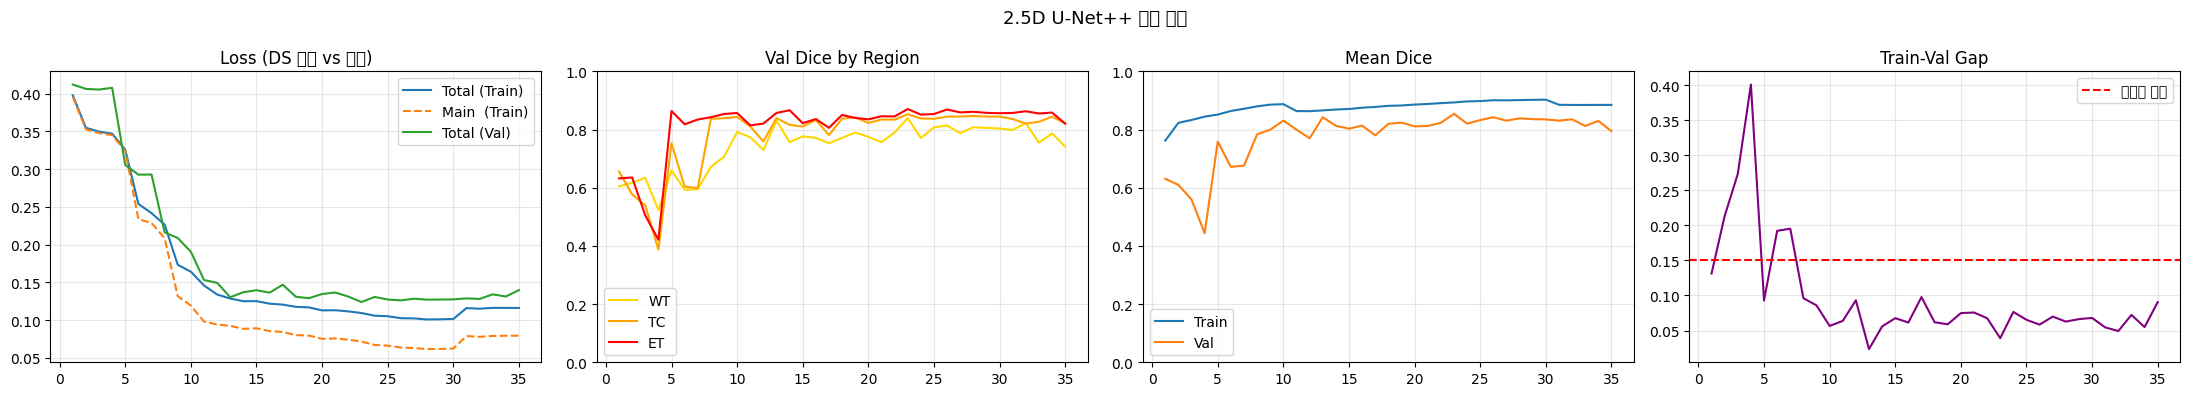

In [11]:
hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

axes[0].plot(hist['epoch'], hist['train_loss'],  label='Total (Train)')
axes[0].plot(hist['epoch'], hist['train_main'],  label='Main  (Train)', ls='--')
axes[0].plot(hist['epoch'], hist['val_loss'],    label='Total (Val)')
axes[0].set_title('Loss (DS 포함 vs 메인)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist['epoch'], hist['val_WT'], label='WT', color='gold')
axes[1].plot(hist['epoch'], hist['val_TC'], label='TC', color='orange')
axes[1].plot(hist['epoch'], hist['val_ET'], label='ET', color='red')
axes[1].set_title('Val Dice by Region'); axes[1].set_ylim(0,1)
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(hist['epoch'], hist['train_dice'], label='Train')
axes[2].plot(hist['epoch'], hist['val_mean'],   label='Val')
axes[2].set_title('Mean Dice'); axes[2].set_ylim(0,1)
axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(hist['epoch'], hist['gap'], color='purple')
axes[3].axhline(0.15, color='red', ls='--', label='과적합 경계')
axes[3].set_title('Train-Val Gap'); axes[3].legend(); axes[3].grid(alpha=0.3)

plt.suptitle('2.5D U-Net++ 학습 곡선', fontsize=13)
plt.tight_layout()
plt.savefig(WORK_DIR / 'curves_unetpp.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Test 평가

In [19]:
model.load_state_dict(torch.load(CKPT_DIR / 'best.pth', map_location=DEVICE))
model.eval()

dice_all, sp_all = [], []
with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Test'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        main_out, _ = model(imgs)
        lg = main_out.cpu().float(); mk = masks.cpu().float()
        dice_all.append(dice_scores(lg, mk))
        sp_all.append(sensitivity_precision(lg, mk))

dice_res = {k: np.mean([s[k] for s in dice_all]) for k in dice_all[0]}
sp_res   = {k: np.mean([s[k] for s in sp_all])   for k in sp_all[0]}

print('='*60)
print('  2.5D U-Net++ Test Results')
print('='*60)
print(f'  {"":6} {"Dice":>8} {"Sens":>8} {"Prec":>8}')
print('-'*60)
for n in ['WT','TC','ET']:
    print(f'  {n:6} {dice_res[n]:8.4f} {sp_res[n+"_sens"]:8.4f} {sp_res[n+"_prec"]:8.4f}')
print('-'*60)
print(f'  {"Mean":6} {dice_res["mean"]:8.4f}')
print('='*60)

row = {'model':'2.5D_UNetPP', 'loss':'Tversky+BCE+DS',
       'Dice_WT':round(dice_res['WT'],4), 'Dice_TC':round(dice_res['TC'],4),
       'Dice_ET':round(dice_res['ET'],4), 'Dice_mean':round(dice_res['mean'],4),
       'Sens_WT':round(sp_res['WT_sens'],4), 'Sens_TC':round(sp_res['TC_sens'],4),
       'Sens_ET':round(sp_res['ET_sens'],4),
       'Prec_WT':round(sp_res['WT_prec'],4), 'Prec_TC':round(sp_res['TC_prec'],4),
       'Prec_ET':round(sp_res['ET_prec'],4)}

path = WORK_DIR / 'metrics_all_models.csv'
df   = pd.read_csv(path) if path.exists() else pd.DataFrame()
pd.concat([df, pd.DataFrame([row])], ignore_index=True).to_csv(path, index=False)
hist.to_csv(WORK_DIR / 'history_unetpp.csv', index=False)
print(f'\n저장 완료: {WORK_DIR}')

Test:  33%|███▎      | 380/1137 [00:54<01:49,  6.91it/s]


KeyboardInterrupt: 

## 12. 예측 시각화

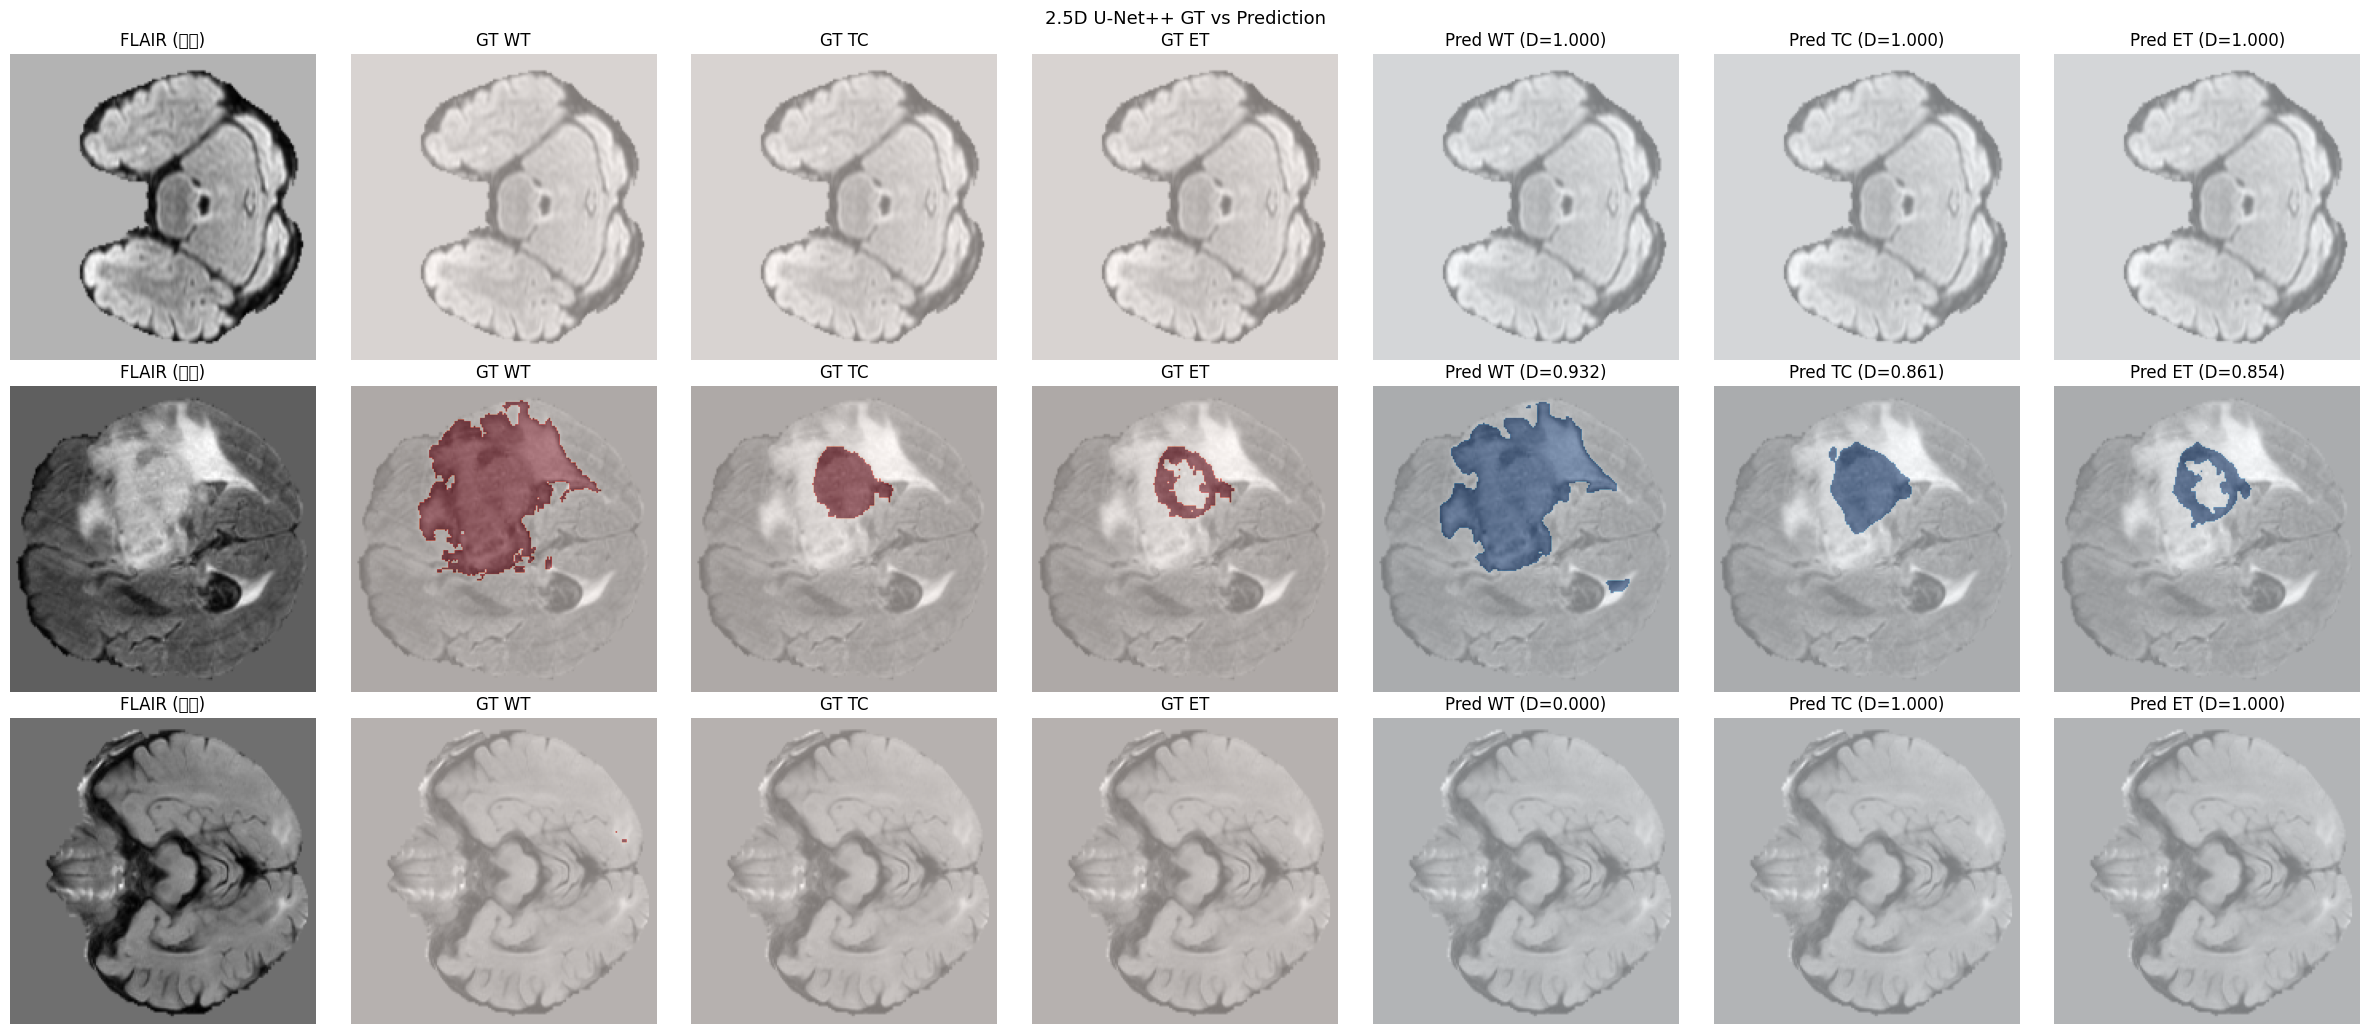

In [13]:
def visualize(model, dataset, device, n=3, thr=0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(n, 7, figsize=(24, 3.5*n))
    if n == 1: axes = axes[np.newaxis,:]
    with torch.no_grad():
        for row, idx in enumerate(indices):
            img, mask = dataset[idx]
            main_out, _ = model(img.unsqueeze(0).to(device))
            pred = (torch.sigmoid(main_out.cpu().float()) > thr).squeeze(0)
            flair = img[N_ADJ * N_MODALITY].numpy()
            axes[row,0].imshow(flair, cmap='gray')
            axes[row,0].set_title('FLAIR (중앙)'); axes[row,0].axis('off')
            for c, name in enumerate(['WT','TC','ET']):
                d = dice_scores(main_out.cpu().float(), mask.unsqueeze(0))[name]
                axes[row,1+c].imshow(flair, cmap='gray')
                axes[row,1+c].imshow(mask[c].numpy(), alpha=0.5, cmap='Reds', vmin=0, vmax=1)
                axes[row,1+c].set_title(f'GT {name}'); axes[row,1+c].axis('off')
                axes[row,4+c].imshow(flair, cmap='gray')
                axes[row,4+c].imshow(pred[c].numpy(), alpha=0.5, cmap='Blues', vmin=0, vmax=1)
                axes[row,4+c].set_title(f'Pred {name} (D={d:.3f})')
                axes[row,4+c].axis('off')
    plt.suptitle('2.5D U-Net++ GT vs Prediction', fontsize=13)
    plt.tight_layout()
    plt.savefig(WORK_DIR / 'viz_unetpp.png', dpi=120, bbox_inches='tight')
    plt.show()

visualize(model, test_ds, DEVICE)

## 13. XAI: GradCAM

> U-Net++의 타겟 레이어:
> - `model.enc4`: bottleneck (가장 추상적, 고수준 의미)
> - `model.enc3`: 공간 해상도와 의미론적 특징의 균형 (권장)

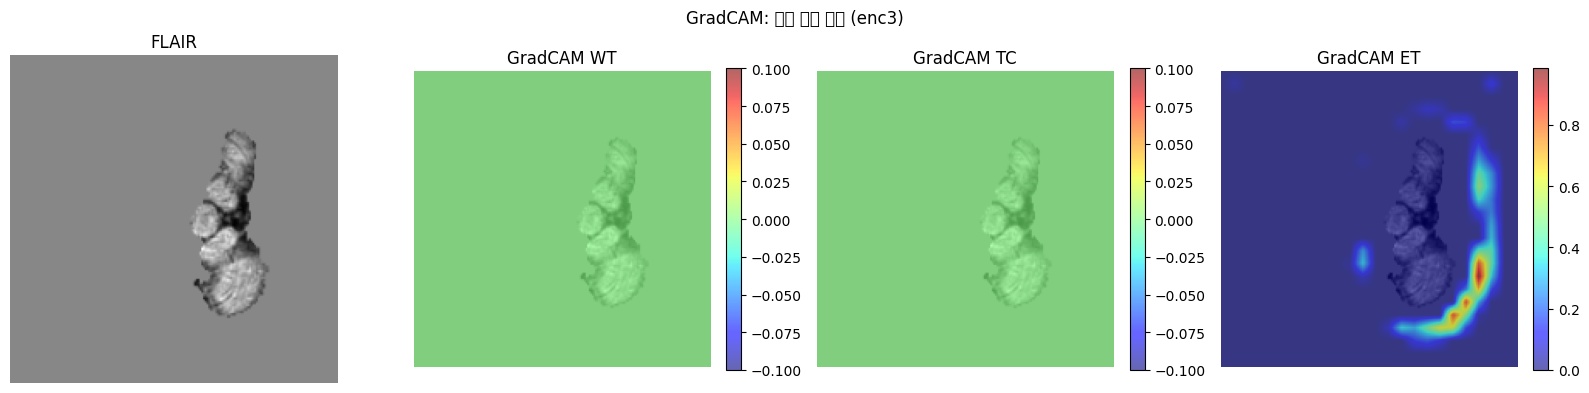

GradCAM 저장: /Users/baiohelseu/brats_work/gradcam_unetpp.png


In [14]:
from scipy.ndimage import zoom as scipy_zoom

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(
            lambda m,i,o: setattr(self,'activations',o.detach()))
        target_layer.register_full_backward_hook(
            lambda m,gi,go: setattr(self,'gradients',go[0].detach()))

    def generate(self, x, class_idx=0):
        self.model.eval()
        x = x.requires_grad_(True)
        main_out, _ = self.model(x)
        self.model.zero_grad()
        main_out[0, class_idx].mean().backward()
        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze(0)
        cam     = torch.relu(cam).cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        H, W    = x.shape[-2:]
        return scipy_zoom(cam, (H/cam.shape[0], W/cam.shape[1]), order=1)


gcam = GradCAM(model, model.enc3)
sample_img, sample_mask = test_ds[0]

fig, axes = plt.subplots(1, 4, figsize=(16,4))
flair = sample_img[N_ADJ*N_MODALITY].numpy()
axes[0].imshow(flair, cmap='gray'); axes[0].set_title('FLAIR'); axes[0].axis('off')

for ci, rname in enumerate(['WT','TC','ET']):
    cam = gcam.generate(sample_img.unsqueeze(0).to(DEVICE), class_idx=ci)
    axes[ci+1].imshow(flair, cmap='gray')
    im = axes[ci+1].imshow(cam, cmap='jet', alpha=0.6)
    axes[ci+1].set_title(f'GradCAM {rname}'); axes[ci+1].axis('off')
    plt.colorbar(im, ax=axes[ci+1], fraction=0.046)

plt.suptitle('GradCAM: 모델 집중 영역 (enc3)', fontsize=12)
plt.tight_layout()
plt.savefig(WORK_DIR / 'gradcam_unetpp.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'GradCAM 저장: {WORK_DIR}/gradcam_unetpp.png')


======================== XAI Efficiency Summary ========================
Method             N   Mean(ms)      Std      Fwd      Bwd      FPS
------------------------------------------------------------------------
GradCAM            3      46.73     4.61    18.84    27.89    21.40
GradCAMpp          3      43.52     0.37    15.90    27.62    22.98


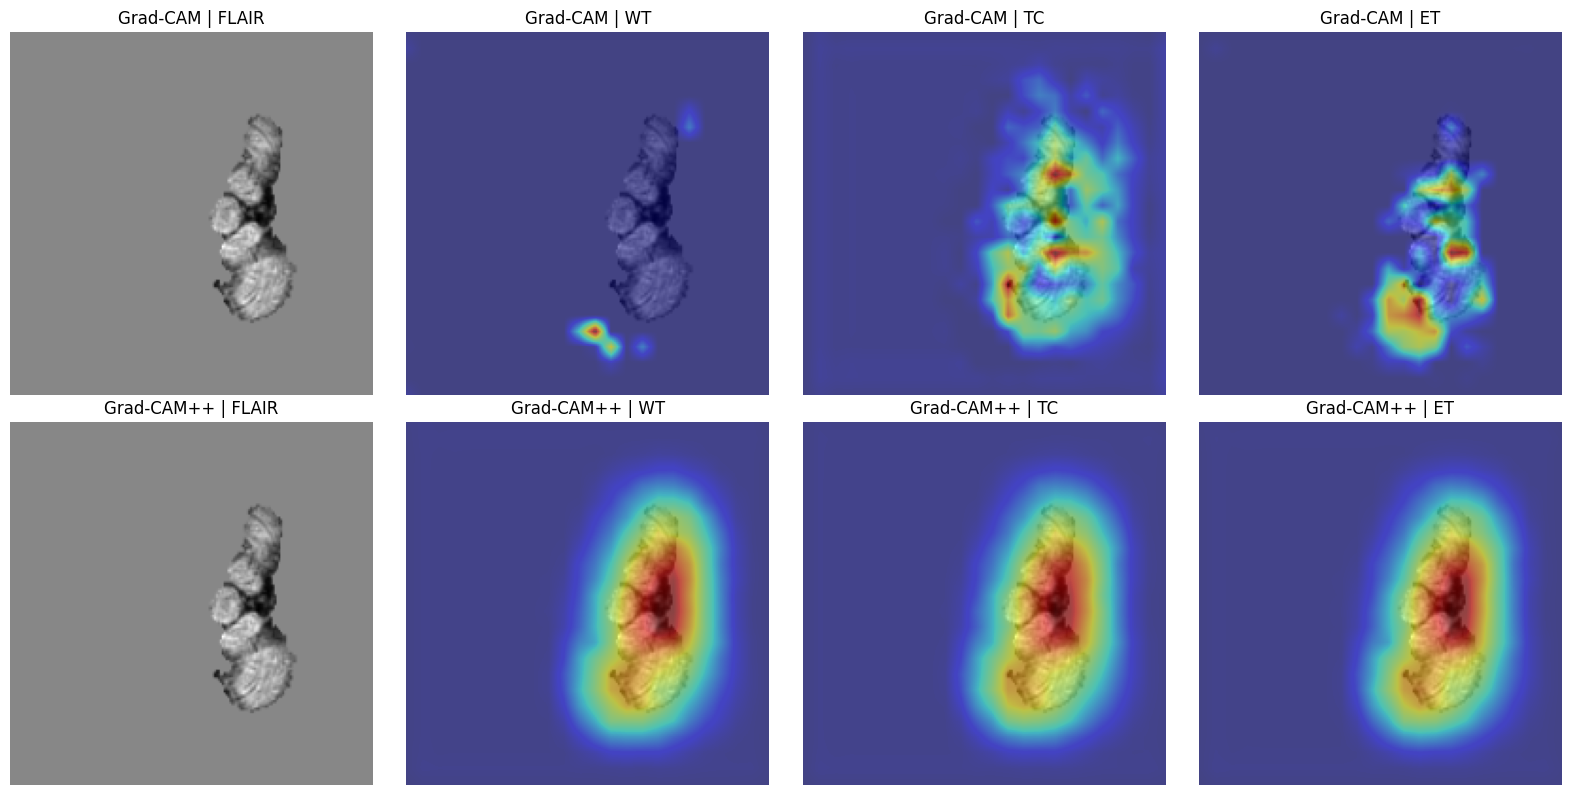

In [46]:
from xai_methods import GradCAM, GradCAMpp, generate_multi_region, get_tracker, reset_tracker
import matplotlib.pyplot as plt

reset_tracker()
sample_img, sample_mask = test_ds[0]

# 두 method를 동일 조건에서 비교
gradcam = GradCAM(model, model.enc3, device=str(DEVICE))
gradcampp = GradCAMpp(model, model.enc3, device=str(DEVICE))

heats_gc   = generate_multi_region(gradcam, sample_img)
heats_gcpp = generate_multi_region(gradcampp, sample_img)

# 효율성 표 출력
get_tracker().print_summary()

# 시각화 (FLAIR 중앙 슬라이스 + WT/TC/ET CAM)
flair = sample_img[N_ADJ * N_MODALITY].numpy()  # 중앙 슬라이스 FLAIR
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, (name, heats) in enumerate([('Grad-CAM', heats_gc), ('Grad-CAM++', heats_gcpp)]):
    axes[row, 0].imshow(flair, cmap='gray'); axes[row, 0].set_title(f'{name} | FLAIR')
    for ci, region in enumerate(['WT', 'TC', 'ET']):
        axes[row, ci+1].imshow(flair, cmap='gray')
        axes[row, ci+1].imshow(heats[region], cmap='jet', alpha=0.5)
        axes[row, ci+1].set_title(f'{name} | {region}')
    for ax in axes[row]: ax.axis('off')
plt.tight_layout(); plt.show()

In [47]:
# === Cell 28: XAI 평가 모듈 import + 의존성 ===
# pip install umap-learn  (UMAP 시각화용, 선택)
# sklearn>=1.3 이면 HDBSCAN 내장. 아니면: pip install hdbscan
import sys
sys.path.append(str(WORK_DIR))   # xai_evaluation.py 를 WORK_DIR 에 두었다면
from xai_evaluation import (
    build_patient_evaluation_table,
    cluster_patients, summarize_clusters,
    analyze_confusion_components,
    plot_cluster_scatter, plot_reliability_diagram, plot_fp_fn_breakdown,
    predict_patient_volume, collect_patient_slice_files,
    expected_calibration_error,
)

In [51]:
import importlib, xai_evaluation
importlib.reload(xai_evaluation)
# 그 다음 다시 import (옛 이름이 캐시되어 있으면 이게 필요)
from xai_evaluation import (
    build_patient_evaluation_table, cluster_patients, summarize_clusters,
    analyze_confusion_components, plot_cluster_scatter,
    plot_reliability_diagram, plot_fp_fn_breakdown,
    predict_patient_volume, collect_patient_slice_files,
    expected_calibration_error,
    compare_xai_methods_cohort, summarize_xai_comparison,
    plot_xai_comparison, plot_insertion_deletion_curves,
)
print('reload 완료 ✓')

reload 완료 ✓


In [52]:
# === Cell 29: 환자 단위 정확도·신뢰도 테이블 ===
# Cell 23 의 슬라이스 평균 Dice 를 환자 3D Dice + HD95 + ECE/Brier 로 교체
model.load_state_dict(torch.load(CKPT_DIR / 'best.pth', map_location=DEVICE))

df_eval = build_patient_evaluation_table(
    model, PROCESSED_DIR, split='test',
    device=DEVICE, batch_size=BATCH_SIZE, threshold=0.5,
)
df_eval.to_csv(WORK_DIR / 'patient_eval_unetpp.csv', index=False)

print('=== 환자 단위 3D 평가 (test cohort) ===')
print(f"환자 수: {len(df_eval)}")
for r in ['WT','TC','ET']:
    d = df_eval[f'{r}_dice']
    h = df_eval[f'{r}_hd95']
    print(f"  {r}: Dice {d.mean():.4f}±{d.std():.4f} (median {d.median():.4f})  "
          f"HD95 {h.mean():.2f}±{h.std():.2f} (NaN={h.isna().sum()})")
print(f"  ECE (WT/TC/ET): "
      f"{df_eval['WT_ece'].mean():.4f} / {df_eval['TC_ece'].mean():.4f} / {df_eval['ET_ece'].mean():.4f}")
print(f"  Brier (WT/TC/ET): "
      f"{df_eval['WT_brier'].mean():.4f} / {df_eval['TC_brier'].mean():.4f} / {df_eval['ET_brier'].mean():.4f}")

patient-level eval (test): 100%|██████████| 75/75 [04:34<00:00,  3.67s/it]

=== 환자 단위 3D 평가 (test cohort) ===
환자 수: 75
  WT: Dice 0.8922±0.1133 (median 0.9200)  HD95 9.98±17.71 (NaN=0)
  TC: Dice 0.8246±0.2002 (median 0.8843)  HD95 9.27±16.54 (NaN=1)
  ET: Dice 0.7586±0.2584 (median 0.8624)  HD95 6.62±16.68 (NaN=5)
  ECE (WT/TC/ET): 0.0043 / 0.0036 / 0.0018
  Brier (WT/TC/ET): 0.0047 / 0.0036 / 0.0019


n_clusters=10, n_noise=35, silhouette=0.321


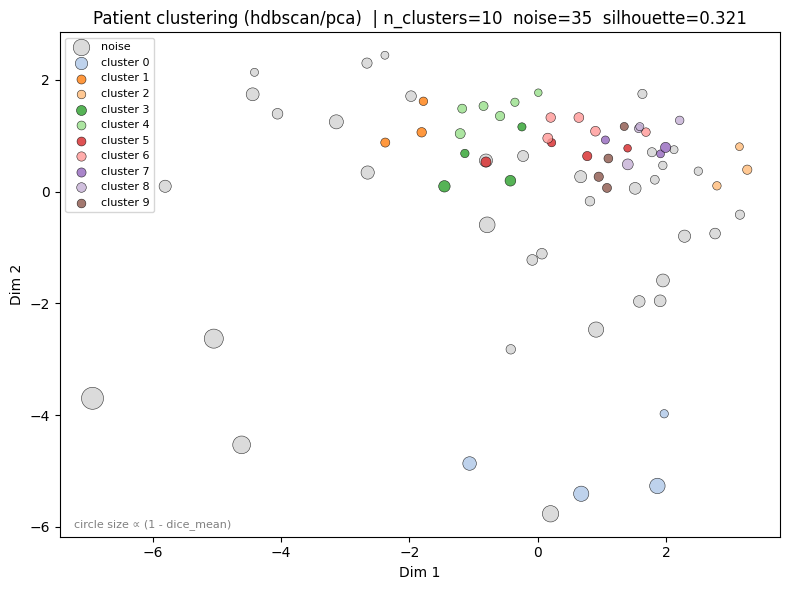

         n_patients  WT_dice_mean  WT_dice_std  TC_dice_mean  TC_dice_std  \
cluster                                                                     
-1               35      0.854718     0.154493      0.752041     0.243466   
 0                4      0.928835     0.028725      0.659546     0.321286   
 1                3      0.927690     0.020823      0.937071     0.005821   
 2                3      0.939317     0.011078      0.928738     0.044556   
 3                4      0.903575     0.055311      0.902376     0.069866   
 4                6      0.937377     0.019145      0.901523     0.059732   
 5                4      0.930481     0.034252      0.934791     0.028492   
 6                5      0.915890     0.022321      0.885909     0.031323   
 7                3      0.927856     0.053730      0.924707     0.047090   
 8                4      0.899051     0.060420      0.916650     0.041296   
 9                4      0.940902     0.018517      0.915015     0.026920   

In [53]:
# === Cell 30 (revised): UMAP→HDBSCAN with log1p ===
# 사전에: pip install umap-learn  (없으면 PCA fallback 됨)
df_clu = cluster_patients(
    df_eval,
    method='hdbscan',
    reducer='umap',                       # 시각화 + 임베딩
    use_reducer_for_clustering=True,      # UMAP 임베딩 공간에서 클러스터링 (핵심)
    reduce_dim=5,                         # UMAP 5D
    min_cluster_size=3,                   # 75명 cohort 에 맞춤
    min_samples=1,
    cluster_selection_method='leaf',      # 작은 실패 그룹까지 발견
    cluster_selection_epsilon=0.0,        # 필요시 0.3 정도 줘서 cluster 합치기
    n_neighbors=15,                       # UMAP 파라미터
)
q = df_clu.attrs['cluster_quality']
print(f"n_clusters={q['n_clusters']}, n_noise={q['n_noise']}, "
      f"silhouette={q['silhouette']:.3f}")

fig, _ = plot_cluster_scatter(df_clu, size_by='dice_mean', size_inverse=True,
                              save_path=WORK_DIR / 'cluster_umap.png')
plt.show()

# 클러스터별 임상·성능 특성
summary = summarize_clusters(df_clu, cols=[
    'WT_dice','TC_dice','ET_dice','dice_mean',
    'WT_hd95','TC_hd95','ET_hd95',
    'WT_voxels','ET_voxels','ET_zero',
    'centroid_x','centroid_y','centroid_z',
    'WT_ece','WT_brier',
])
print(summary)
summary.to_csv(WORK_DIR / 'cluster_summary.csv')

# 실패 그룹 (cluster=-1 또는 최저 평균 Dice cluster)
noise_pids = df_clu[df_clu['cluster'] == -1]['patient'].tolist()
print(f'\n[Noise/outlier] {len(noise_pids)}명: {noise_pids[:10]}')

FP/FN/TP analysis (test): 100%|██████████| 75/75 [04:21<00:00,  3.48s/it]


=== 영역별 over/under-segmentation 경향 ===
  WT: over-seg 56%, under-seg 31%, 평균 FP isolated frac (환각도) 0.364
  TC: over-seg 69%, under-seg 19%, 평균 FP isolated frac (환각도) 0.402
  ET: over-seg 61%, under-seg 27%, 평균 FP isolated frac (환각도) 0.256


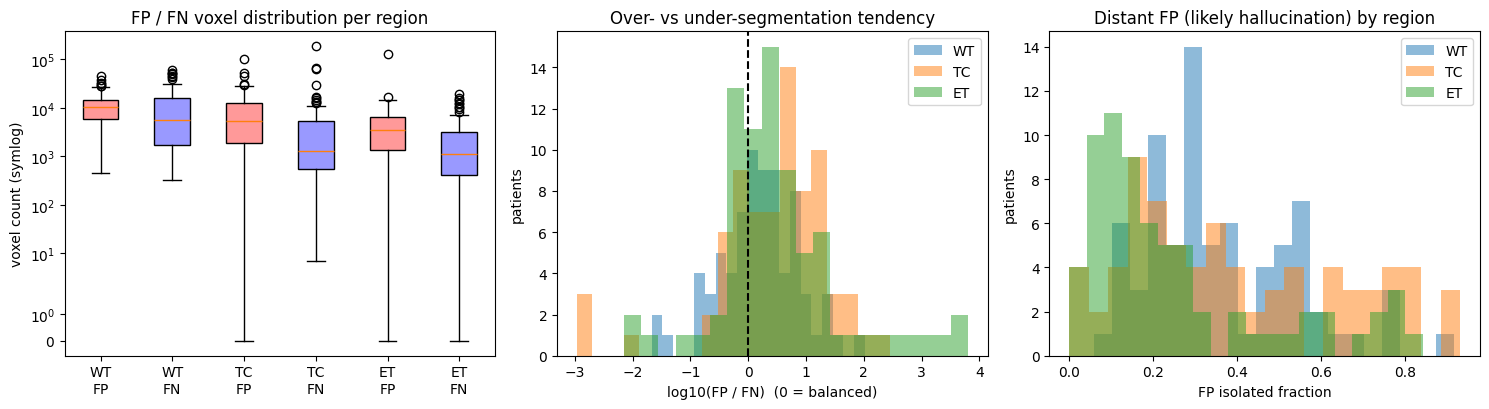

In [54]:
# === Cell 31: FP/FN/TP 심화 (환자×영역) ===
df_conf = analyze_confusion_components(
    model, PROCESSED_DIR, split='test',
    device=DEVICE, batch_size=BATCH_SIZE, threshold=0.5,
)
df_conf.to_csv(WORK_DIR / 'confusion_components_unetpp.csv', index=False)

print('=== 영역별 over/under-segmentation 경향 ===')
for r in ['WT','TC','ET']:
    sub = df_conf[df_conf['region'] == r]
    over  = (sub['fp_fn_ratio'] > 1.2).mean()
    under = (sub['fp_fn_ratio'] < 0.8).mean()
    halluc = sub['fp_isolated_frac'].mean(skipna=True)
    print(f"  {r}: over-seg {over:.0%}, under-seg {under:.0%}, "
          f"평균 FP isolated frac (환각도) {halluc:.3f}")

plot_fp_fn_breakdown(df_conf, save_path=WORK_DIR / 'fp_fn_breakdown.png')
plt.show()

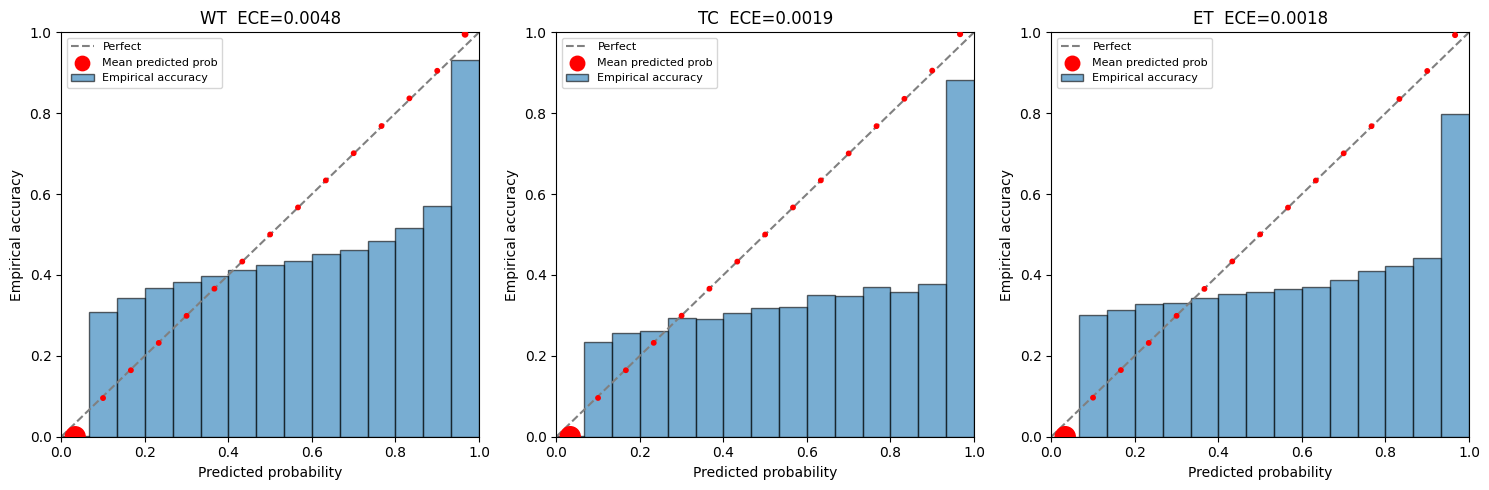

In [55]:
# === Cell 32: Reliability diagram (cohort 전체 모은 확률 vs GT) ===
# 큰 환자가 메모리 부담이면 일부 샘플만
groups = collect_patient_slice_files(PROCESSED_DIR, 'test')
all_probs, all_gts = [], []
for pid, files in list(groups.items())[:20]:   # 20명 표본으로 충분
    p, g = predict_patient_volume(model, files, device=DEVICE,
                                  batch_size=BATCH_SIZE)
    all_probs.append(p); all_gts.append(g)
P = np.concatenate(all_probs); G = np.concatenate(all_gts)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, name in enumerate(['WT','TC','ET']):
    plot_reliability_diagram(P[:, i], G[:, i], title=name, ax=axes[i])
fig.savefig(WORK_DIR / 'reliability_diagram.png', dpi=120, bbox_inches='tight')
plt.show()

정성 분석 대상(최하 Dice 3명): ['BraTS20_Training_325', 'BraTS20_Training_141', 'BraTS20_Training_263']


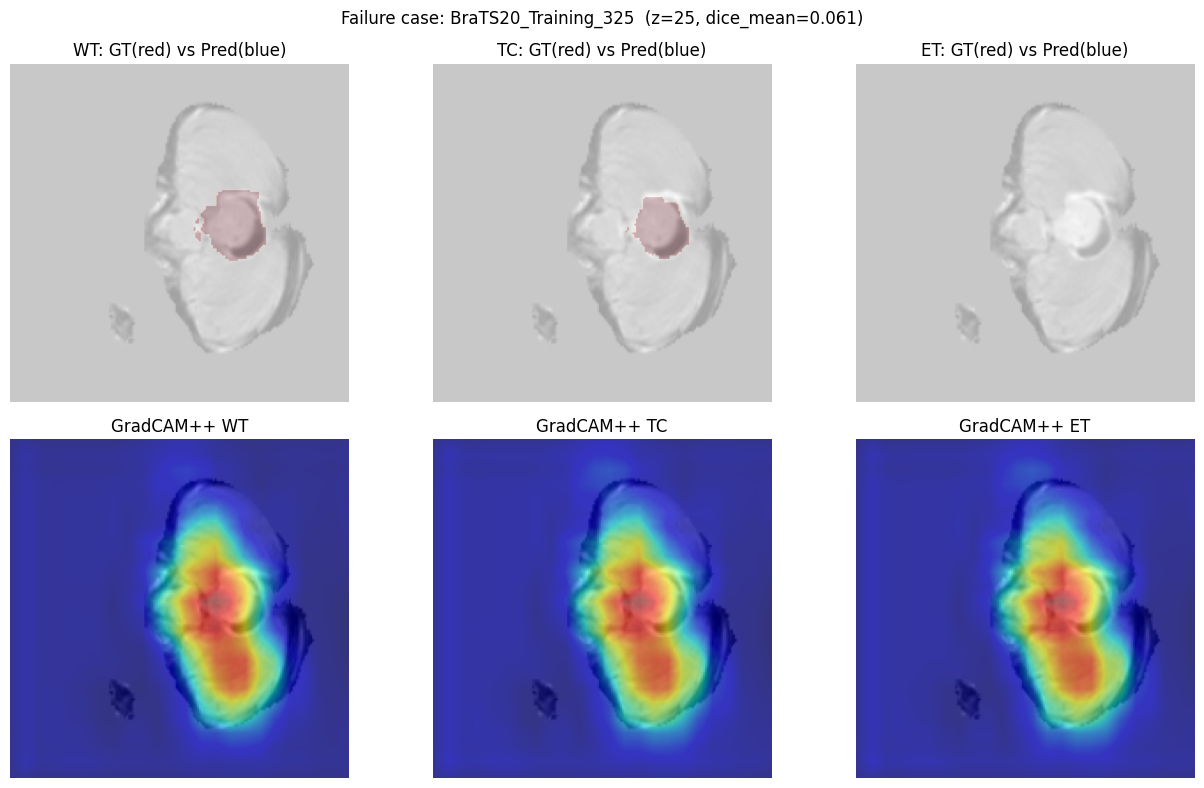

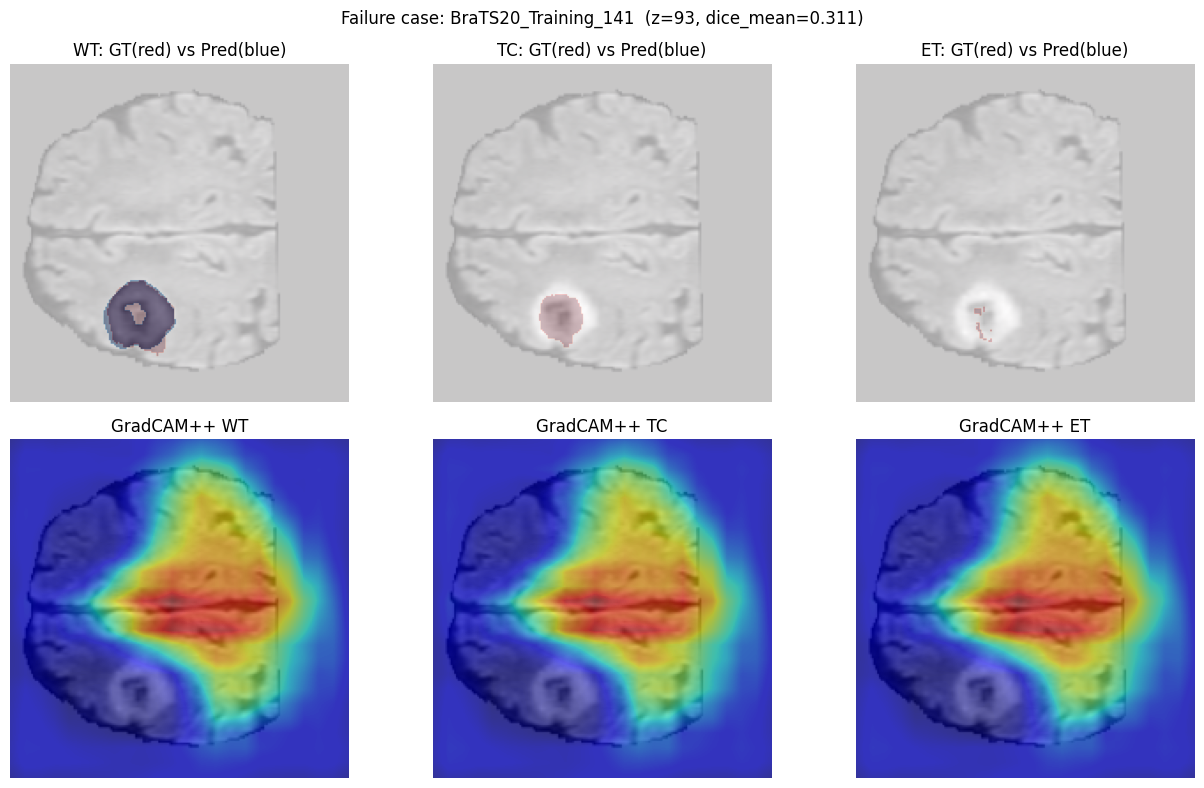

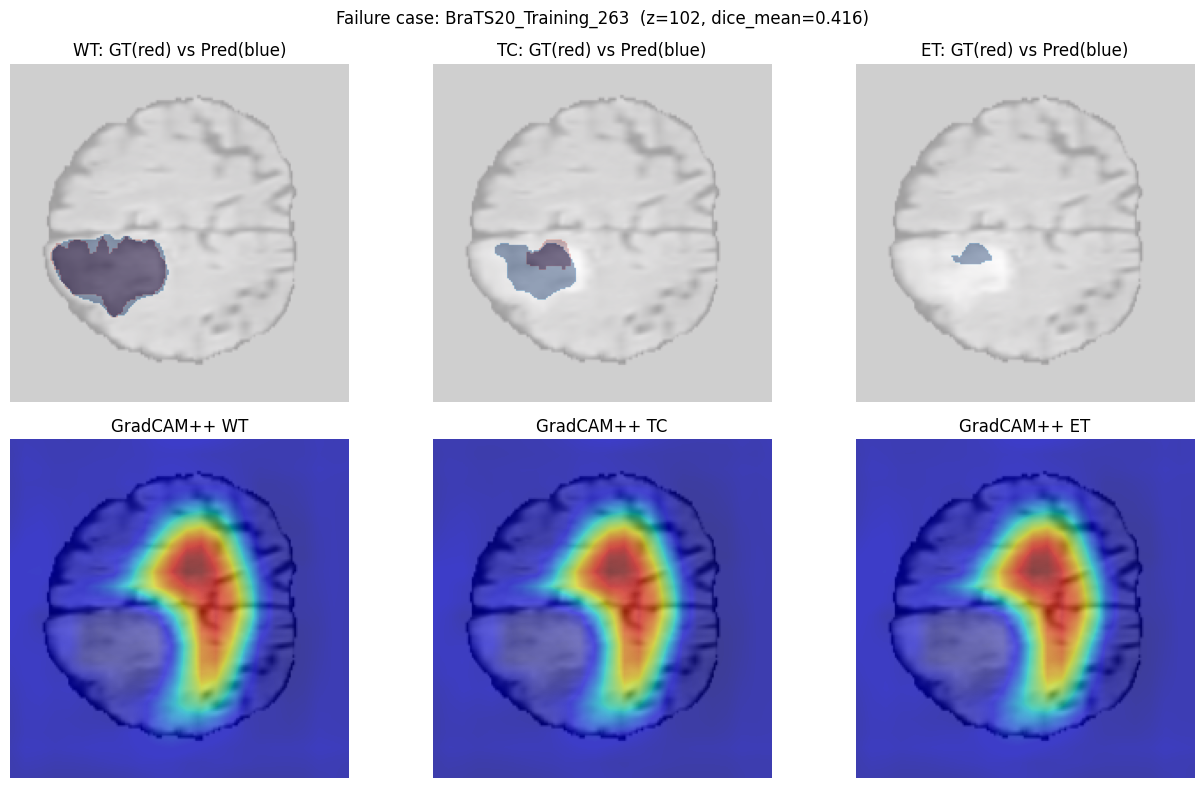

In [56]:
# === Cell 33: 실패 환자 케이스 정성 시각화 ===
# 최하 Dice 환자 3명을 골라 GradCAM 까지 같이 비교 — 모델이 어디 보고 틀렸는지
from xai_methods import GradCAMpp, generate_multi_region, reset_tracker
reset_tracker()

worst = df_eval.nsmallest(3, 'dice_mean')['patient'].tolist()
print('정성 분석 대상(최하 Dice 3명):', worst)

cam = GradCAMpp(model, model.enc3, device=str(DEVICE))
for pid in worst:
    files = groups[pid]
    # 종양이 가장 큰 슬라이스 1장 골라서
    best_z = 0; best_area = 0
    for z, f in enumerate(files):
        d = np.load(f, allow_pickle=True).item()
        area = d['mask'].sum()
        if area > best_area:
            best_area, best_z = area, z
    d = np.load(files[best_z], allow_pickle=True).item()
    img  = torch.from_numpy(d['image']).permute(2,0,1).unsqueeze(0).to(DEVICE)
    mask = torch.from_numpy(d['mask']).permute(2,0,1)

    with torch.no_grad():
        pr = (torch.sigmoid(model(img)[0])[0].cpu() > 0.5).float()
    heats = generate_multi_region(cam, img.squeeze(0))

    fig, ax = plt.subplots(2, 3, figsize=(13, 8))
    flair = d['image'][:, :, N_ADJ * N_MODALITY]
    for c, name in enumerate(['WT','TC','ET']):
        ax[0,c].imshow(flair, cmap='gray')
        ax[0,c].imshow(mask[c], alpha=0.4, cmap='Reds')
        ax[0,c].imshow(pr[c],   alpha=0.4, cmap='Blues')
        ax[0,c].set_title(f'{name}: GT(red) vs Pred(blue)'); ax[0,c].axis('off')
        ax[1,c].imshow(flair, cmap='gray')
        ax[1,c].imshow(heats[name], alpha=0.55, cmap='jet')
        ax[1,c].set_title(f'GradCAM++ {name}'); ax[1,c].axis('off')
    fig.suptitle(f'Failure case: {pid}  (z={best_z}, dice_mean='
                 f'{df_eval.set_index("patient").loc[pid,"dice_mean"]:.3f})')
    fig.tight_layout(); plt.show()
cam.remove_hooks()

XAI cohort compare (test): 100%|██████████| 75/75 [05:46<00:00,  4.62s/it]


rows: 450 — shape: (450, 14)

=== XAI 메서드 영역별 평균 (mean) ===
                  loc_dice_mean  loc_iou_mean  loc_hd95_mean  \
method    region                                               
GradCAM   ET             0.1784        0.1113        32.4139   
          TC             0.4132        0.3092        29.8710   
          WT             0.4060        0.2793        24.6884   
GradCAMpp ET             0.0742        0.0412        93.5651   
          TC             0.2034        0.1282        87.9544   
          WT             0.1803        0.1073        70.0315   

                  energy_in_gt_mean  pointing_game_hit_mean  ins_auc_mean  \
method    region                                                            
GradCAM   ET                 0.1373                  0.2000        0.0227   
          TC                 0.4925                  0.6267        0.0532   
          WT                 0.6568                  0.7867        0.1115   
GradCAMpp ET                 0.0297       

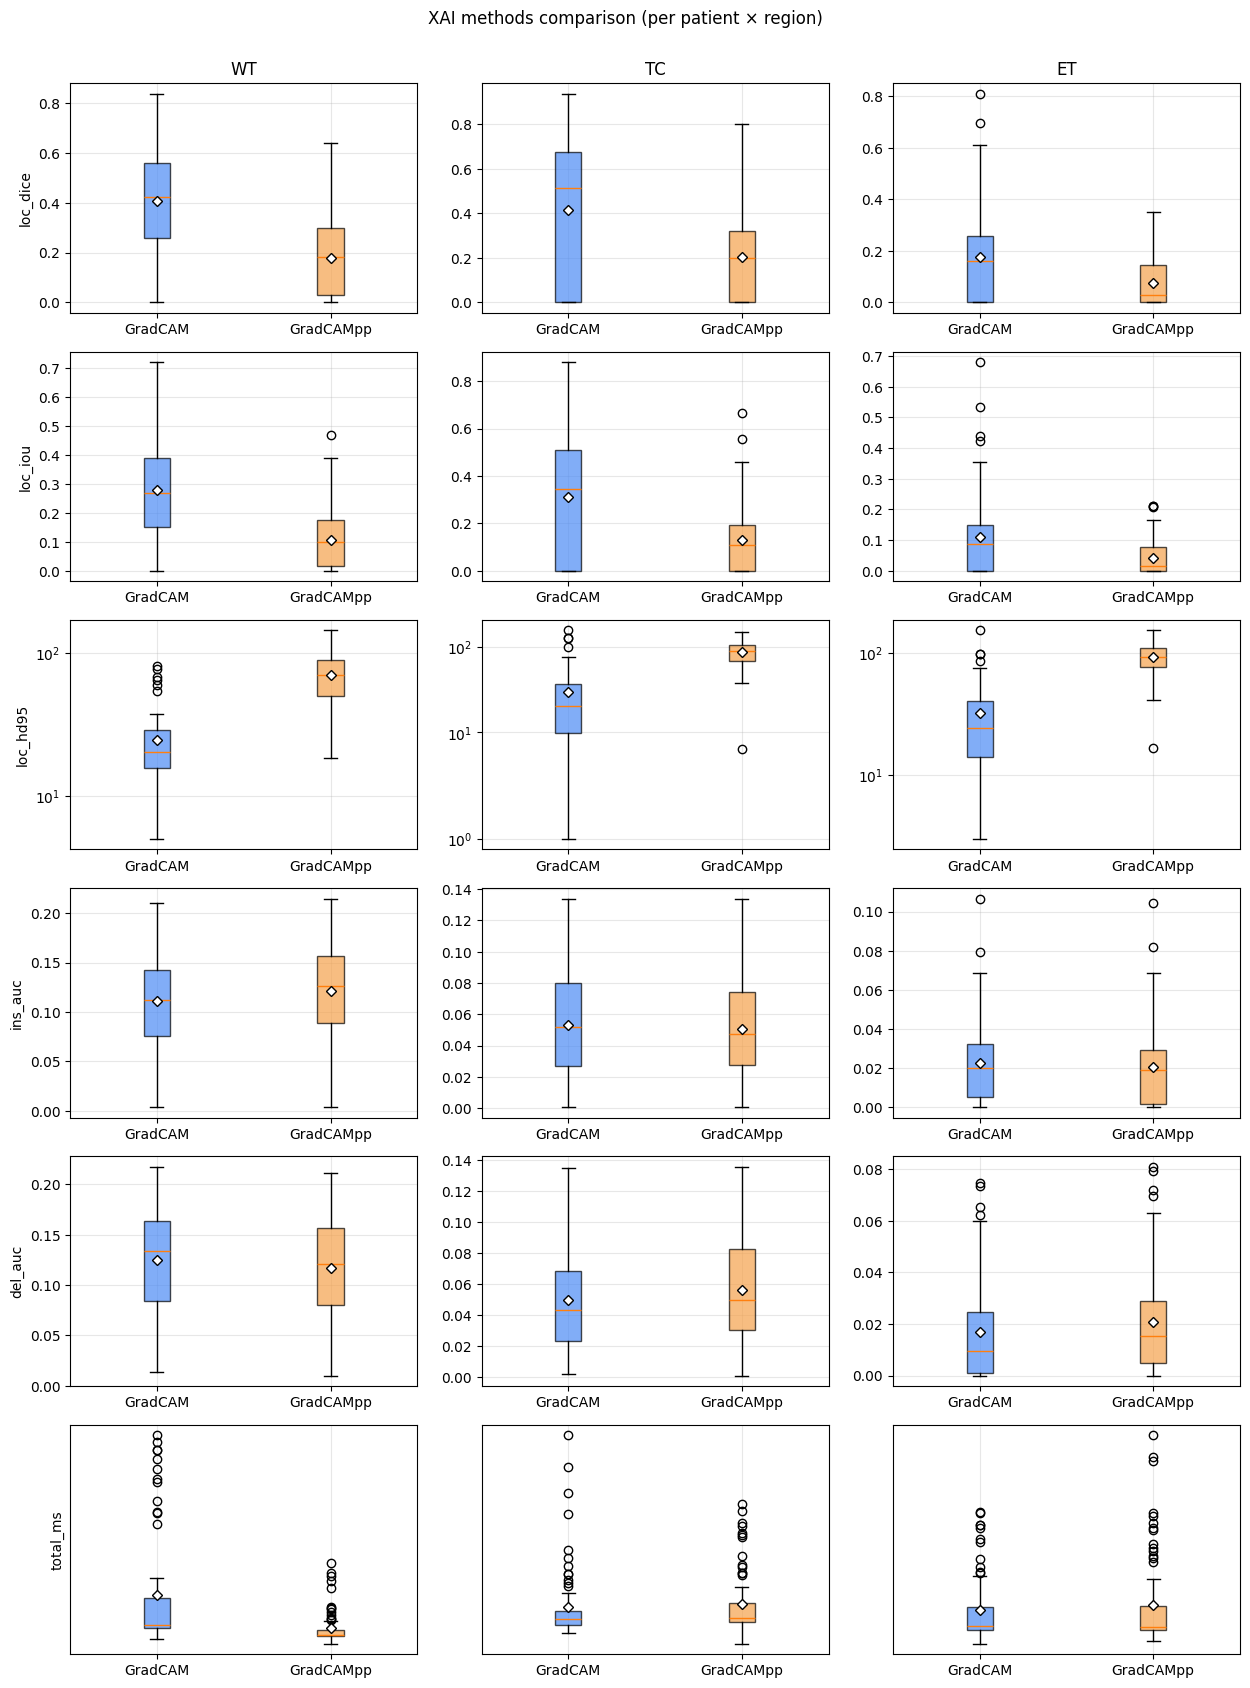

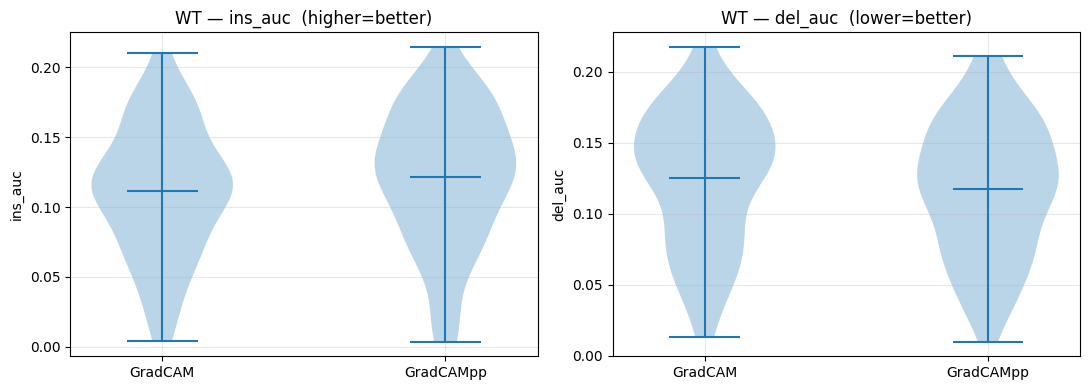

In [57]:
# === Cell 34: XAI 메서드 cohort 비교 ===
from xai_methods import GradCAM, GradCAMpp, reset_tracker
from xai_evaluation import (
    compare_xai_methods_cohort, summarize_xai_comparison,
    plot_xai_comparison, plot_insertion_deletion_curves,
)

reset_tracker()
df_xai = compare_xai_methods_cohort(
    model, PROCESSED_DIR, split='test',
    target_layer=model.enc3,                       # U-Net++ target
    methods={'GradCAM': GradCAM, 'GradCAMpp': GradCAMpp},
    device=str(DEVICE),
    class_indices=(0, 1, 2),                       # WT, TC, ET
    threshold='otsu',                              # heatmap binarize 방법
    n_ins_del_steps=20,                            # Insertion/Deletion step 수
    baseline='blur',                               # 강력 추천 (zero 는 OOD)
    blur_sigma=10.0,
    slice_strategy='largest',                      # 환자별 WT 가장 큰 슬라이스
    max_patients=None,                             # 전체 75명
)
df_xai.to_csv(WORK_DIR / 'xai_comparison_unetpp.csv', index=False)
print('rows:', len(df_xai), '— shape:', df_xai.shape)

# 영역별 평균 + Wilcoxon
summary_xai = summarize_xai_comparison(df_xai, paired_test=True)
print('\n=== XAI 메서드 영역별 평균 (mean) ===')
mean_cols = [c for c in summary_xai.columns if c.endswith('_mean')]
print(summary_xai[mean_cols].round(4))

tests = summary_xai.attrs.get('paired_tests', {})
if tests:
    print('\n=== Paired Wilcoxon (환자 매칭) ===')
    for (r, metric), info in tests.items():
        sig = '***' if info['p_value']<0.001 else '**' if info['p_value']<0.01 else '*' if info['p_value']<0.05 else 'ns'
        print(f"  [{r:3} / {metric:9}] "
              f"{list(info.keys())[0]}={info[list(info.keys())[0]]:.4f}  "
              f"{list(info.keys())[1]}={info[list(info.keys())[1]]:.4f}  "
              f"diff={info['diff_mean']:+.4f}  p={info['p_value']:.4g} {sig}")

fig = plot_xai_comparison(df_xai, save_path=WORK_DIR / 'xai_comparison_boxes.png')
plt.show()

fig = plot_insertion_deletion_curves(df_xai, region='WT',
                                     save_path=WORK_DIR / 'xai_insdel_WT.png')
plt.show()

In [60]:
# === Cell 35: fair XAI 재평가 (percentile threshold + AUPRC) ===
from sklearn.metrics import average_precision_score
from xai_methods import GradCAM, GradCAMpp
from xai_evaluation import (
    collect_patient_slice_files,
    insertion_deletion_aucs,
    dice_iou_sens_spec_prec,
)

def heatmap_auprc(h, g):
    """threshold-free 비교 — heatmap을 score로 보고 PR-AUC."""
    g = (g > 0.5).astype(int).ravel()
    if g.sum() == 0:
        return np.nan
    return float(average_precision_score(g, h.ravel()))

def top_percent_mask(h, pct=10):
    """heatmap 상위 pct%를 1로."""
    if h.max() <= 0:
        return np.zeros_like(h, dtype=np.uint8)
    thr = np.percentile(h, 100 - pct)
    return (h > thr).astype(np.uint8)

def _largest_z(files, region_idx=0):
    best_z, best_a = 0, -1
    for z, f in enumerate(files):
        d = np.load(f, allow_pickle=True).item()
        a = d['mask'][:, :, region_idx].sum()
        if a > best_a: best_a, best_z = a, z
    return best_z

groups = collect_patient_slice_files(PROCESSED_DIR, 'test')
records = []
methods = {'GradCAM': GradCAM, 'GradCAMpp': GradCAMpp}

for pid, files in tqdm(list(groups.items()), desc='fair re-eval'):
    z = _largest_z(files, region_idx=0)
    d = np.load(files[z], allow_pickle=True).item()
    img = torch.from_numpy(d['image']).permute(2, 0, 1).float()
    mask = d['mask']

    for mname, Mcls in methods.items():
        cam = Mcls(model, model.enc3, device=str(DEVICE))
        try:
            for ci, rname in enumerate(['WT', 'TC', 'ET']):
                h = cam.generate(img, class_idx=ci)
                g = mask[:, :, ci]
                rec = {'patient': pid, 'method': mname, 'region': rname}
                # AUPRC — threshold-free
                rec['auprc'] = heatmap_auprc(h, g)
                # 여러 percentile 에서 dice/iou — fair binarize
                for pct in [5, 10, 20, 30]:
                    pred = top_percent_mask(h, pct=pct)
                    m = dice_iou_sens_spec_prec(pred, (g > 0.5).astype(np.uint8))
                    rec[f'dice_top{pct}'] = m['dice']
                    rec[f'iou_top{pct}']  = m['iou']
                records.append(rec)
        finally:
            cam.remove_hooks()

df_fair = pd.DataFrame(records)
df_fair.to_csv(WORK_DIR / 'xai_fair_eval.csv', index=False)

# 요약
print('=== AUPRC (threshold-free, 가장 공정) ===')
print(df_fair.groupby(['method', 'region'])['auprc']
      .agg(['mean', 'std', 'median']).round(4))

print('\n=== top-X% binarize 후 dice (percentile별) ===')
for pct in [5, 10, 20, 30]:
    print(f'\n--- top {pct}% ---')
    print(df_fair.groupby(['method', 'region'])[f'dice_top{pct}']
          .agg(['mean', 'std']).round(4))

# paired Wilcoxon — AUPRC
from scipy.stats import wilcoxon
print('\n=== Paired Wilcoxon (AUPRC) ===')
for r in ['WT', 'TC', 'ET']:
    a = df_fair[(df_fair['method']=='GradCAM')   & (df_fair['region']==r)].set_index('patient')['auprc']
    b = df_fair[(df_fair['method']=='GradCAMpp') & (df_fair['region']==r)].set_index('patient')['auprc']
    common = a.index.intersection(b.index)
    a, b = a.loc[common].dropna(), b.loc[common].dropna()
    if len(a) < 5: continue
    stat, p = wilcoxon(a, b)
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  [{r}] GradCAM={a.mean():.4f}  GradCAMpp={b.mean():.4f}  "
          f"diff={a.mean()-b.mean():+.4f}  p={p:.3g} {sig}")

fair re-eval: 100%|██████████| 75/75 [00:36<00:00,  2.05it/s]

=== AUPRC (threshold-free, 가장 공정) ===
                    mean     std  median
method    region                        
GradCAM   ET      0.1606  0.1808  0.0991
          TC      0.4664  0.3530  0.5511
          WT      0.5059  0.2773  0.5481
GradCAMpp ET      0.0679  0.0901  0.0357
          TC      0.2366  0.2331  0.1422
          WT      0.2002  0.1633  0.1654

=== top-X% binarize 후 dice (percentile별) ===

--- top 5% ---
                    mean     std
method    region                
GradCAM   ET      0.1779  0.1843
          TC      0.4095  0.3066
          WT      0.4025  0.1918
GradCAMpp ET      0.0706  0.1018
          TC      0.2012  0.2164
          WT      0.1532  0.1573

--- top 10% ---
                    mean     std
method    region                
GradCAM   ET      0.1798  0.1780
          TC      0.4062  0.3083
          WT      0.4861  0.2290
GradCAMpp ET      0.0741  0.0993
          TC      0.1942  0.1902
          WT      0.1680  0.1531

--- top 20% ---
          